Imports

In [ ]:
# !pip install tensorflow

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sn
import os

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


load and preprocess the data

In [3]:
# used paths
working_dir = '/content/drive/MyDrive/School projects/PFE Project/Article level Datasets'
data_path = os.path.join(working_dir, 'datasets')
models_path =  os.path.join(working_dir, 'models')
visualisations_path = os.path.join(working_dir, 'visualizations')
if not os.path.exists(models_path):
  os.mkdir(models_path)
if not os.path.exists(visualisations_path):
  os.mkdir(visualisations_path)

In [4]:
# knowledge based feature selected scada datasets

# scada_30_Knw_selected = selected_path+'/knowledge_selected_scada_30.csv'
# scada_60_Knw_selected = data_path+'/knowledge_selected_scada_60.csv'
scada_60_combained_classes = data_path+'/knowledge_selected_scada_60_merged_classes.csv'

# scada_30 = os.path.join(data_path,'scada_labeled_merged_30days.csv')
# scada_60= os.path.join(data_path,'scada_labeled_merged_60days.csv')

In [6]:
# scada_30 = pd.read_csv(scada_30_Knw_selected)
scada_60 = pd.read_csv(scada_60_combained_classes)


In [ ]:
# scada_60 = scada_60.iloc[:, 1:].copy()
# scada_60.head()

In [8]:
scada_60 = scada_60.iloc[:,1:]
scada_60.head()

,Timestamp,Turbine_ID,Gen_RPM_Avg,Gen_RPM_Std,Gen_Bear_Temp_Avg,Gen_Bear2_Temp_Avg,Gen_SlipRing_Temp_Avg,Gear_Oil_Temp_Avg,Gear_Bear_Temp_Avg,Hyd_Oil_Temp_Avg,...,Amb_WindSpeed_Std,Nac_Direction_Avg,Avg_Windspeed1,Var_Windspeed1,Avg_Windspeed2,Avg_Winddirection2,Avg_AmbientTemp,Avg_Humidity,Avg_Pressure,Label
0,2016-01-01 00:00:00+00:00,T01,1249.0,9.0,41.0,37,25,44,48,30,...,0.9,218.5,5.1,0.21,5.1,236.0,17.0,90.0,1018.0,0
1,2016-01-01 00:10:00+00:00,T01,999.7,435.9,41.0,37,25,44,48,30,...,0.9,218.5,5.1,0.09,5.2,236.0,17.0,87.0,1018.0,0
2,2016-01-01 00:20:00+00:00,T01,774.0,486.1,41.0,37,25,43,46,30,...,1.0,213.3,5.7,0.26,5.8,236.0,17.0,90.0,1018.0,0
3,2016-01-01 00:30:00+00:00,T01,1257.1,17.0,40.0,36,25,44,48,30,...,1.1,222.4,6.3,0.11,6.4,236.0,17.0,90.0,1018.0,0
4,2016-01-01 00:40:00+00:00,T01,1257.7,18.0,40.0,36,25,44,48,30,...,1.2,222.4,6.2,0.27,6.3,236.0,17.0,90.0,1018.0,0


In [9]:
display(scada_60.groupby(by = ['Label']).count())

,Timestamp,Turbine_ID,Gen_RPM_Avg,Gen_RPM_Std,Gen_Bear_Temp_Avg,Gen_Bear2_Temp_Avg,Gen_SlipRing_Temp_Avg,Gear_Oil_Temp_Avg,Gear_Bear_Temp_Avg,Hyd_Oil_Temp_Avg,...,Amb_WindSpeed_Avg,Amb_WindSpeed_Std,Nac_Direction_Avg,Avg_Windspeed1,Var_Windspeed1,Avg_Windspeed2,Avg_Winddirection2,Avg_AmbientTemp,Avg_Humidity,Avg_Pressure
Label,,,,,,,,,,,,,,,,,,,,,
0,268559,268559,268559,268559,268558,268559,268559,268559,268559,268559,...,268559,268559,268559,208924,208924,208924,208924,208924,208921,208924
1,148582,148582,148582,148582,148579,148582,148582,148582,148582,148582,...,148582,148582,148582,137330,137330,137330,137330,137330,137333,137330


In [ ]:
# # Merge Generator Bearing (4) into Generator (3)

# scada_60['Label'] = scada_60['Label'].replace({4: 3})  # Merge class 4 into 3
# scada_60['Label'] = scada_60['Label'].replace({5: 4})  # Shift Hydraulic to 4

Data cleaning & Handling Missing values

In [10]:
def handle_missing_values(df, drop_threshold=0.5):
    """
    Handle missing values using forward/backward imputation and row dropping

    Parameters:
    - df: SCADA dataframe (sorted by Turbine_ID, Timestamp)
    - drop_threshold: if row has > this fraction of missing values, drop it

    Returns:
    - cleaned dataframe
    """
    print(f"Initial shape: {df.shape}")
    print(f"Initial missing values: {df.isnull().sum().sum()}")

    # Step 1: Drop rows with too many missing values
    missing_ratio = df.isnull().sum(axis=1) / df.shape[1]
    rows_to_drop = missing_ratio > drop_threshold
    df_clean = df[~rows_to_drop].copy()

    print(f"Dropped {rows_to_drop.sum()} rows with >{drop_threshold*100}% missing")

    # Step 2: Forward fill then backward fill within each turbine
    df_clean = df_clean.groupby('Turbine_ID', group_keys=False).apply(
        lambda group: group.fillna(method='ffill').fillna(method='bfill')
    )

    # Step 3: Drop any remaining rows with missing values
    df_clean = df_clean.dropna()

    print(f"Final shape: {df_clean.shape}")
    print(f"Final missing values: {df_clean.isnull().sum().sum()}")

    return df_clean

In [11]:
scada_60['Timestamp'] = pd.to_datetime(scada_60['Timestamp'])
# scada_60['Timestamp'] = pd.to_datetime(scada_60['Timestamp'])

In [12]:
scada_60_cleaned =handle_missing_values(scada_60)

Initial shape: (417141, 29)
Initial missing values: 496213
Dropped 0 rows with >50.0% missing


/tmp/ipython-input-1673384312.py:24: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  lambda group: group.fillna(method='ffill').fillna(method='bfill')


Final shape: (417141, 29)
Final missing values: 0


/tmp/ipython-input-1673384312.py:23: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_clean = df_clean.groupby('Turbine_ID', group_keys=False).apply(


In [13]:
scada_60_cleaned = scada_60_cleaned.sort_values(['Turbine_ID', 'Timestamp'])
# scada_60_cleaned = scada_60_cleaned.sort_values(['Turbine_ID', 'Timestamp'])

In [14]:
scada_60_cleaned.shape

(417141, 29)

# SCADA 60

## Time serie split

we are here in this section experimenting techniques and approach to split the data into train, validation and test set with the most efficient way based on our data contsraints

### Basic spliting experimentations

In [15]:
from datetime import timedelta
def ts_split(data, test_size = 92, val_size = 61) :

  data['Timestamp'] = pd.to_datetime(data['Timestamp'])
  data = data.sort_values(['Turbine_ID','Timestamp'])

  # let's define the start time of every set:
  max_time = data['Timestamp'].max()
  test_start_time = max_time - timedelta(days = test_size)
  validation_start_time = test_start_time - timedelta(days = val_size)

  train_set = data[data['Timestamp'] < validation_start_time]
  test_set = data[data['Timestamp'] >= test_start_time]
  val_set = data[(data['Timestamp'] >= validation_start_time) & (data['Timestamp'] < test_start_time)]

  return train_set, val_set, test_set

In [16]:
scada_60_2MDroped = scada_60_cleaned[scada_60_cleaned['Timestamp'] < '2017-11-01'].copy()

In [17]:
scada_60_train, scada_60_val, scada_60_test = ts_split(scada_60_2MDroped)

In [18]:
scada_60_val.tail()

,Timestamp,Turbine_ID,Gen_RPM_Avg,Gen_RPM_Std,Gen_Bear_Temp_Avg,Gen_Bear2_Temp_Avg,Gen_SlipRing_Temp_Avg,Gear_Oil_Temp_Avg,Gear_Bear_Temp_Avg,Hyd_Oil_Temp_Avg,...,Amb_WindSpeed_Std,Nac_Direction_Avg,Avg_Windspeed1,Var_Windspeed1,Avg_Windspeed2,Avg_Winddirection2,Avg_AmbientTemp,Avg_Humidity,Avg_Pressure,Label
395123,2017-07-31 23:00:00+00:00,T11,228.6,15.1,50.0,39,28,49,50,37,...,0.4,240.2,3.5,0.20,3.6,236.0,21.0,73.0,1005.0,1
395124,2017-07-31 23:10:00+00:00,T11,240.2,18.8,48.0,38,28,48,48,37,...,0.5,240.2,4.1,0.04,4.2,236.0,22.0,72.0,1005.0,1
395125,2017-07-31 23:20:00+00:00,T11,249.8,18.4,46.0,37,28,48,48,37,...,0.5,252.8,3.9,0.03,3.9,236.0,22.0,72.0,1005.0,1
395126,2017-07-31 23:30:00+00:00,T11,885.3,456.1,44.0,37,28,48,48,37,...,0.6,247.6,3.8,0.10,3.9,236.0,22.0,72.0,1005.0,1
395127,2017-07-31 23:40:00+00:00,T11,801.8,469.3,43.0,37,29,50,52,37,...,0.8,252.1,4.0,0.03,4.1,236.0,21.0,73.0,1005.0,1


In [19]:
display(scada_60_test.groupby(['Label']).count())

,Timestamp,Turbine_ID,Gen_RPM_Avg,Gen_RPM_Std,Gen_Bear_Temp_Avg,Gen_Bear2_Temp_Avg,Gen_SlipRing_Temp_Avg,Gear_Oil_Temp_Avg,Gear_Bear_Temp_Avg,Hyd_Oil_Temp_Avg,...,Amb_WindSpeed_Avg,Amb_WindSpeed_Std,Nac_Direction_Avg,Avg_Windspeed1,Var_Windspeed1,Avg_Windspeed2,Avg_Winddirection2,Avg_AmbientTemp,Avg_Humidity,Avg_Pressure
Label,,,,,,,,,,,,,,,,,,,,,
0,22735,22735,22735,22735,22735,22735,22735,22735,22735,22735,...,22735,22735,22735,22735,22735,22735,22735,22735,22735,22735
1,30146,30146,30146,30146,30146,30146,30146,30146,30146,30146,...,30146,30146,30146,30146,30146,30146,30146,30146,30146,30146


In [20]:
display(scada_60_val.groupby(['Label']).count())

,Timestamp,Turbine_ID,Gen_RPM_Avg,Gen_RPM_Std,Gen_Bear_Temp_Avg,Gen_Bear2_Temp_Avg,Gen_SlipRing_Temp_Avg,Gear_Oil_Temp_Avg,Gear_Bear_Temp_Avg,Hyd_Oil_Temp_Avg,...,Amb_WindSpeed_Avg,Amb_WindSpeed_Std,Nac_Direction_Avg,Avg_Windspeed1,Var_Windspeed1,Avg_Windspeed2,Avg_Winddirection2,Avg_AmbientTemp,Avg_Humidity,Avg_Pressure
Label,,,,,,,,,,,,,,,,,,,,,
0,11134,11134,11134,11134,11134,11134,11134,11134,11134,11134,...,11134,11134,11134,11134,11134,11134,11134,11134,11134,11134
1,23285,23285,23285,23285,23285,23285,23285,23285,23285,23285,...,23285,23285,23285,23285,23285,23285,23285,23285,23285,23285


### Analysing Failure class distribution over time

Overall class distribution:
Label
0    233503
1    148582
Name: count, dtype: int64

Percentage:
Label
0    61.112841
1    38.887159
Name: proportion, dtype: float64


Failure distribution by turbine:
Label           0      1
Turbine_ID              
T01         78903  17020
T06         46246  47928
T07         46682  49273
T11         61672  34361


Monthly failure distribution:
Label          0      1
YearMonth              
2016-01    13794   4062
2016-02     8894   7802
2016-03     8589   9235
2016-04    12481   4799
2016-05    10209   7546
2016-06     4318  12954
2016-07     6448   9794
2016-08     7946   9258
2016-09     8603   8621
2016-10    11459   6183
2016-11    17054      0
2016-12    17856      0
2017-01    17845      0
2017-02    15661    467
2017-03    13374   4458
2017-04    11767   5509
2017-05    13339   4464
2017-06     9311   7907
2017-07     1820  15381
2017-08     2927  14850
2017-09     6962  10282
2017-10    12846   5010


/tmp/ipython-input-4194090702.py:19: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  scada_60_2MDroped['YearMonth'] = scada_60_2MDroped['Timestamp'].dt.to_period('M')


KeyError: 2

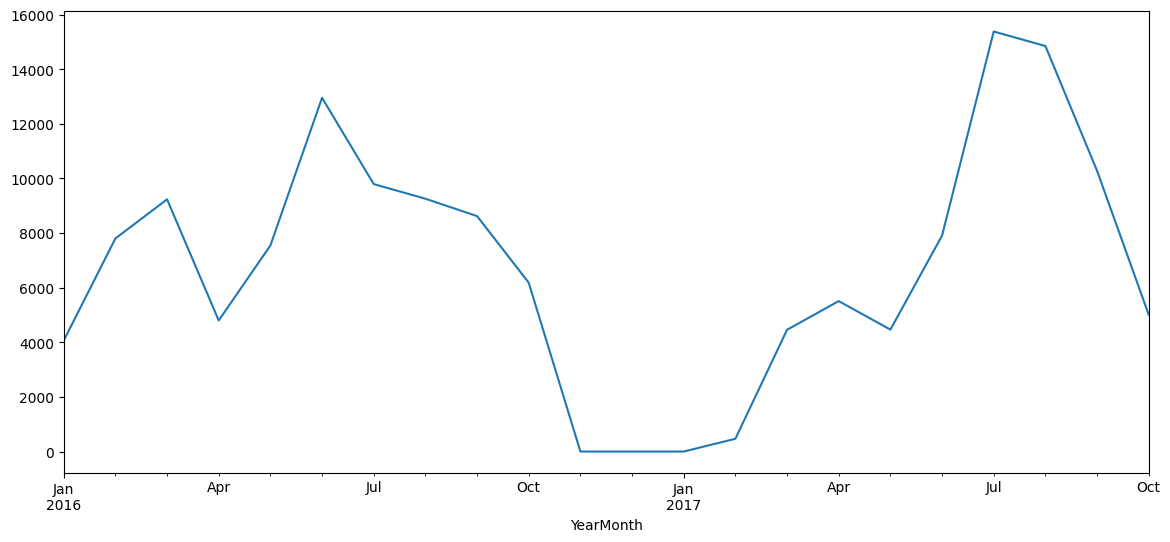

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming your dataframe is 'df' with columns: 'Timestamp', 'Turbine_ID', 'Target'
# Convert Timestamp to datetime if not already
scada_60_2MDroped['Timestamp'] = pd.to_datetime(scada_60['Timestamp'])

# 1. Overall failure counts
print("Overall class distribution:")
print(scada_60_2MDroped['Label'].value_counts().sort_index())
print("\nPercentage:")
print(scada_60_2MDroped['Label'].value_counts(normalize=True).sort_index() * 100)

# 2. Failure distribution by turbine
print("\n\nFailure distribution by turbine:")
print(pd.crosstab(scada_60_2MDroped['Turbine_ID'], scada_60_2MDroped['Label']))

# 3. Failure distribution -0over time (monthly
scada_60_2MDroped['YearMonth'] = scada_60_2MDroped['Timestamp'].dt.to_period('M')
monthly_failures = scada_60_2MDroped.groupby(['YearMonth', 'Label']).size().unstack(fill_value=0)
print("\n\nMonthly failure distribution:")
print(monthly_failures)

# 4. Visual check - plot failures over time
plt.figure(figsize=(14, 6))
for failure_class in range(1, 5):
    monthly_failures[failure_class].plot(label=f'Class {failure_class}')
plt.xlabel('Month')
plt.ylabel('Count')
plt.title('Failure Distribution Over Time')
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(visualisations_path, 'failure_distri_over_time.png'))
plt.show()

# 5. Check last 60 days
last_60_days = scada_60_2MDroped[scada_60_2MDroped['Timestamp'] >= scada_60_2MDroped['Timestamp'].max() - pd.Timedelta(days=60)]
print("\n\nLast 60 days distribution:")
print(last_60_days['Label'].value_counts().sort_index())

## time serie windowing

In [22]:
# Separate features and target
X_train = scada_60_train.drop(['Label', 'Timestamp', 'Turbine_ID'], axis=1)
y_train = scada_60_train['Label']

# Data standarisation using StandardScaler:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Store feature names for later use
feature_names = X_train.columns

In [23]:
# Separate features and target
X_test = scada_60_test.drop(['Label', 'Timestamp', 'Turbine_ID'], axis=1)
y_test = scada_60_test['Label']

# Data standarisation using StandardScaler:
X_test_scaled = scaler.transform(X_test)

In [24]:
# Separate features and target
X_val= scada_60_val.drop(['Label', 'Timestamp', 'Turbine_ID'], axis=1)
y_val = scada_60_val['Label']

# Data standarisation using StandardScaler:
X_val_scaled = scaler.transform(X_val)

In [25]:
def create_windows(data, turbine_ids, labels, window_size=144, stride=24):
    """
    Create windowed data from time series.
    Window size of 144 represents 24 hours (6 samples per hour * 24 hours)
    Stride of 24 represents 4 hours (6 samples per hour * 4 hours)
    """
    X_windows = []
    y_windows = []
    turbine_id_windows = []

    # For each turbine
    for turbine_id in np.unique(turbine_ids):
        turbine_mask = turbine_ids == turbine_id
        turbine_data = data[turbine_mask] # X
        turbine_labels = labels[turbine_mask] # y

        # Create windows for this turbine
        for i in range(0, len(turbine_data) - window_size + 1, stride):
            X_windows.append(turbine_data[i:i+window_size])
            # Label the window by the last value's label
            # For predictive maintenance, we want to predict failures ahead of time
            y_windows.append(turbine_labels[i+window_size-1])
            turbine_id_windows.append(turbine_id)

    return np.array(X_windows), np.array(y_windows), np.array(turbine_id_windows)

# Get turbine IDs for each split
turbine_ids_train = scada_60_train['Turbine_ID'].values
turbine_ids_val = scada_60_val['Turbine_ID'].values
turbine_ids_test = scada_60_test['Turbine_ID'].values

# Create windows for each split
window_size = 144  # 24 hours of data
stride = 4     # 4 hours stride

X_train_windowed, y_train_windowed, _ = create_windows(X_train_scaled, turbine_ids_train, y_train.values,
                                                            window_size=window_size,
                                                            stride=stride)
X_val_windowed, y_val_windowed, _ = create_windows(X_val_scaled, turbine_ids_val, y_val.values,
                                                          window_size=window_size,
                                                          stride=stride)
X_test_windowed, y_test_windowed, _ = create_windows(X_test_scaled, turbine_ids_test, y_test.values,
                                                            window_size=window_size,
                                                            stride=stride)

print(f"Train windowed data shape: {X_train_windowed.shape}")
print(f"Train windowed labels shape: {y_train_windowed.shape}")
print(f"Validation windowed data shape: {X_val_windowed.shape}")
print(f"Validation windowed labels shape: {y_val_windowed.shape}")
print(f"Test windowed data shape: {X_test_windowed.shape}")
print(f"Test windowed labels shape: {y_test_windowed.shape}")

Train windowed data shape: (73554, 144, 26)
Train windowed labels shape: (73554,)
Validation windowed data shape: (8463, 144, 26)
Validation windowed labels shape: (8463,)
Test windowed data shape: (13079, 144, 26)
Test windowed labels shape: (13079,)


In [26]:
from sklearn.preprocessing import StandardScaler

# The data is already split into train, val, and test and windowed in the previous step.
# Rename variables for clarity and consistency with model training expectations.

X_train = X_train_windowed
y_train = y_train_windowed
X_val = X_val_windowed
y_val = y_val_windowed
X_test = X_test_windowed
y_test = y_test_windowed

print(f"Train set shape: {X_train.shape}")
print(f"Validation set shape: {X_val.shape}")
print(f"Test set shape: {X_test.shape}")

Train set shape: (73554, 144, 26)
Validation set shape: (8463, 144, 26)
Test set shape: (13079, 144, 26)


In [27]:
unique, counts = np.unique(y_train_windowed, return_counts=True)
print("Class distribution (Training Data):", dict(zip(unique, counts)))

# Calculate initial bias
# b_i = log(N_i / N_total)
total_samples = np.sum(counts)
# Add epsilon to avoid log(0) if any count is 0, though unlikely here
initial_bias = np.log(counts / total_samples + 1e-7)
print("Initial Bias:", initial_bias)

# 1. Compute class weights (Keeping for reference, but disabling for this run)
from sklearn.utils.class_weight import compute_class_weight
class_weights = compute_class_weight('balanced', classes=unique, y=y_train_windowed)
class_weights = np.sqrt(class_weights) # Dampen the weights to prevent over-correction
class_weight_dict = dict(zip(unique, class_weights))
print("Class weights (Training Data):", class_weight_dict)

Class distribution (Training Data): {np.int64(0): np.int64(49767), np.int64(1): np.int64(23787)}
Initial Bias: [-0.39066757 -1.12888031]
Class weights (Training Data): {np.int64(0): np.float64(0.8596415903582442), np.int64(1): np.float64(1.2434213314040383)}


In [28]:
# One-hot encode the labels
# Determine the total number of unique classes from the original data
num_classes_overall = len(np.unique(y_train)) # Get unique classes from the original full dataset
print(f"Total number of classes in the dataset: {num_classes_overall}")

# Use the total number of classes for one-hot encoding all splits
y_train_onehot = tf.keras.utils.to_categorical(y_train, num_classes_overall)
y_val_onehot = tf.keras.utils.to_categorical(y_val, num_classes_overall)
y_test_onehot = tf.keras.utils.to_categorical(y_test, num_classes_overall)


# Create TF datasets
batch_size = 32

train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train_onehot)).batch(batch_size).prefetch(tf.data.AUTOTUNE)
val_dataset = tf.data.Dataset.from_tensor_slices((X_val, y_val_onehot)).batch(batch_size).prefetch(tf.data.AUTOTUNE)
test_dataset = tf.data.Dataset.from_tensor_slices((X_test, y_test_onehot)).batch(batch_size).prefetch(tf.data.AUTOTUNE)

Total number of classes in the dataset: 2


In [35]:
def build_model(input_shape, output_bias=None):
    if output_bias is not None:
        output_bias = tf.keras.initializers.Constant(output_bias)

    inputs = tf.keras.Input(shape=input_shape)

    # --- Simplified CNN-BLSTM Architecture (EXP-005) ---

    # 1. CNN Block (Feature Extraction)
    # Reduced complexity: 2 layers, fewer filters
    x = tf.keras.layers.Conv1D(filters=32, kernel_size=5, activation='relu', padding='same')(inputs)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPooling1D(pool_size=2)(x)

    x = tf.keras.layers.Conv1D(filters=64, kernel_size=3, activation='relu', padding='same')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPooling1D(pool_size=2)(x)

    # 2. Bidirectional LSTM Block (Temporal Dependencies)
    # Single BLSTM layer
    x = tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64, return_sequences=False))(x)
    x = tf.keras.layers.Dropout(0.3)(x)

    # 3. Output Block
    # num_classes_overall is defined globally
    outputs = tf.keras.layers.Dense(num_classes_overall, activation='softmax', bias_initializer=output_bias)(x)

    model = tf.keras.Model(inputs, outputs)
    return model

In [41]:
class FocalLoss(tf.keras.losses.Loss):
    def __init__(self, gamma=2.0, alpha=0.25, name='focal_loss'):
        super(FocalLoss, self).__init__(name=name)
        self.gamma = gamma
        self.alpha = alpha

    def call(self, y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)

        # Calculate cross entropy
        cross_entropy = -y_true * tf.math.log(y_pred)

        # Calculate focal weights: (1 - p_t)^gamma where p_t is the probability of the true class
        # For correct predictions (high p_t), weight is low; for wrong predictions (low p_t), weight is high
        p_t = tf.reduce_sum(y_true * y_pred, axis=-1, keepdims=True)
        focal_weight = tf.math.pow(1.0 - p_t, self.gamma)

        # Apply focal weight to all classes
        loss = focal_weight * cross_entropy

        # Apply alpha balancing factor
        alpha_weight = y_true * self.alpha + (1.0 - y_true) * (1.0 - self.alpha)
        loss = alpha_weight * loss

        return tf.reduce_sum(loss, axis=-1)

In [42]:
# Build and compile model within strategy scope
model = build_model(input_shape=(X_train.shape[1], X_train.shape[2]), output_bias=initial_bias)

# EXP-006: Simplified CNN-BLSTM + Focal Loss + Class Weights
# Combining stable architecture (EXP-005) with imbalance handling (Focal Loss)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=FocalLoss(gamma=2.0, alpha=0.25),
    metrics=['accuracy',
              tf.keras.metrics.Precision(),
              tf.keras.metrics.Recall(),
              tf.keras.metrics.AUC()]
)
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 144, 26)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_6 (Conv1D)               │ (None, 144, 32)        │         4,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 144, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_6 (MaxPooling1D)  │ (None, 72, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ (None, 72, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 72, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_7 (MaxPooling1D)  │ (None, 36, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 128)            │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 77,090 (301.13 KB)

 Trainable params: 76,898 (300.38 KB)

 Non-trainable params: 192 (768.00 B)

In [43]:
# Callbacks
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=20,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath=os.path.join(models_path,'model_Knw_Selected_scada_60_2Classes_Strid_4_simple_CNN-LSTM.keras'),
        monitor='val_loss',
        save_best_only=True
    )
]

# Train the model
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=50,
    callbacks=callbacks
    # class_weight=class_weight_dict  # Disabled class weights
)

Epoch 1/50
2299/2299 ━━━━━━━━━━━━━━━━━━━━ 47s 18ms/step - accuracy: 0.9316 - auc_3: 0.9658 - loss: 0.0207 - precision_3: 0.9316 - recall_3: 0.9316 - val_accuracy: 0.3164 - val_auc_3: 0.2855 - val_loss: 0.0703 - val_precision_3: 0.3164 - val_recall_3: 0.3164 - learning_rate: 0.0010
Epoch 2/50
2299/2299 ━━━━━━━━━━━━━━━━━━━━ 30s 13ms/step - accuracy: 0.8653 - auc_3: 0.9322 - loss: 0.0237 - precision_3: 0.8653 - recall_3: 0.8653 - val_accuracy: 0.3215 - val_auc_3: 0.3703 - val_loss: 0.0903 - val_precision_3: 0.3215 - val_recall_3: 0.3215 - learning_rate: 0.0010
Epoch 3/50
2299/2299 ━━━━━━━━━━━━━━━━━━━━ 32s 14ms/step - accuracy: 0.8631 - auc_3: 0.9258 - loss: 0.0252 - precision_3: 0.8631 - recall_3: 0.8631 - val_accuracy: 0.3164 - val_auc_3: 0.3233 - val_loss: 0.0493 - val_precision_3: 0.3164 - val_recall_3: 0.3164 - learning_rate: 0.0010
Epoch 4/50
2299/2299 ━━━━━━━━━━━━━━━━━━━━ 31s 14ms/step - accuracy: 0.8348 - auc_3: 0.8925 - loss: 0.0294 - precision_3: 0.8348 - recall_3: 0.8348 - val_a

409/409 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4913 - auc_3: 0.5332 - loss: 0.0489 - precision_3: 0.4913 - recall_3: 0.4913
Test loss: 0.0525493323802948
Test accuracy: 0.4927746653556824
409/409 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step

Classification Report:
              precision    recall  f1-score   support

           0       0.42      0.41      0.41      5683
           1       0.55      0.56      0.55      7396

    accuracy                           0.49     13079
   macro avg       0.48      0.48      0.48     13079
weighted avg       0.49      0.49      0.49     13079



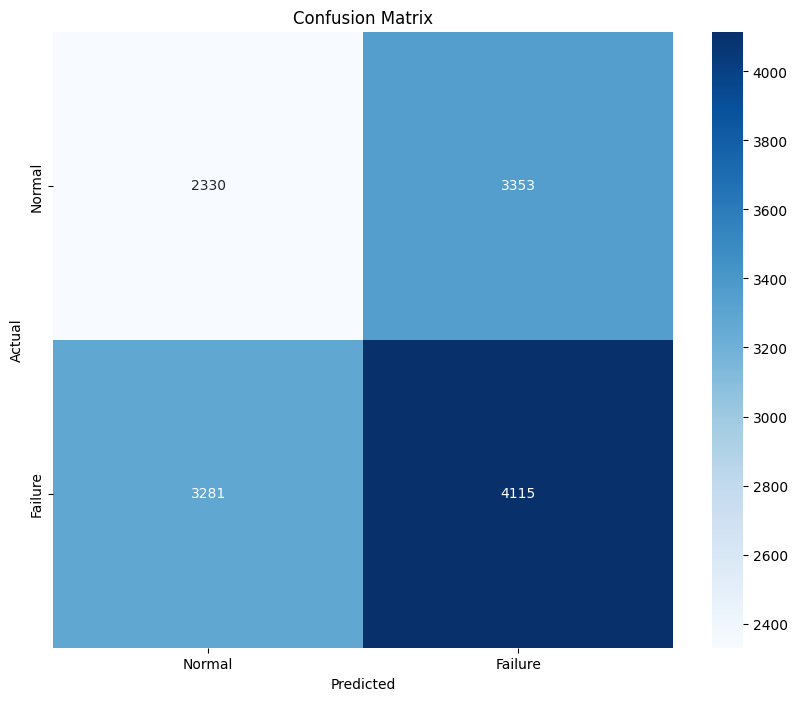

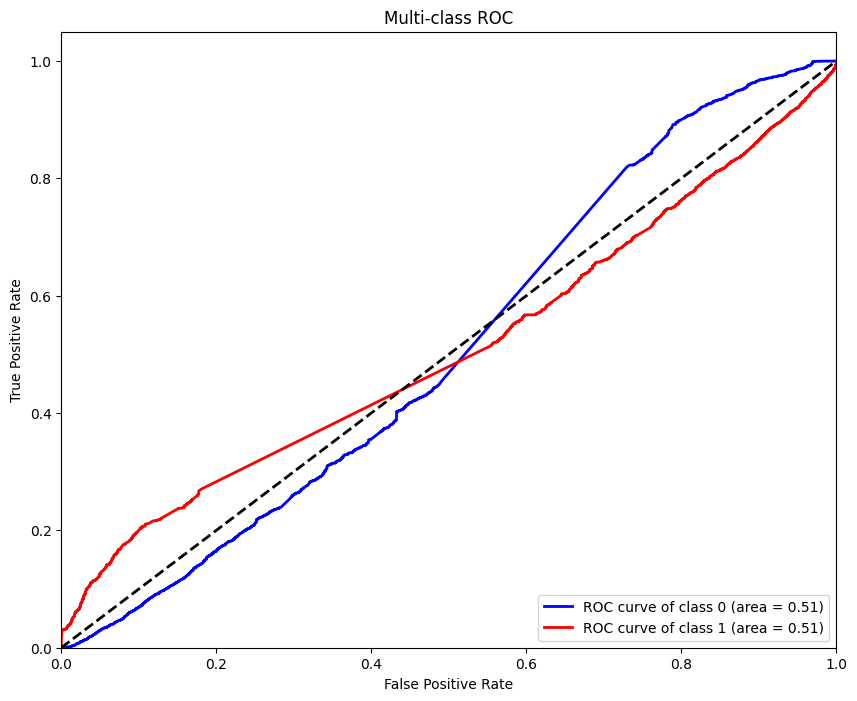

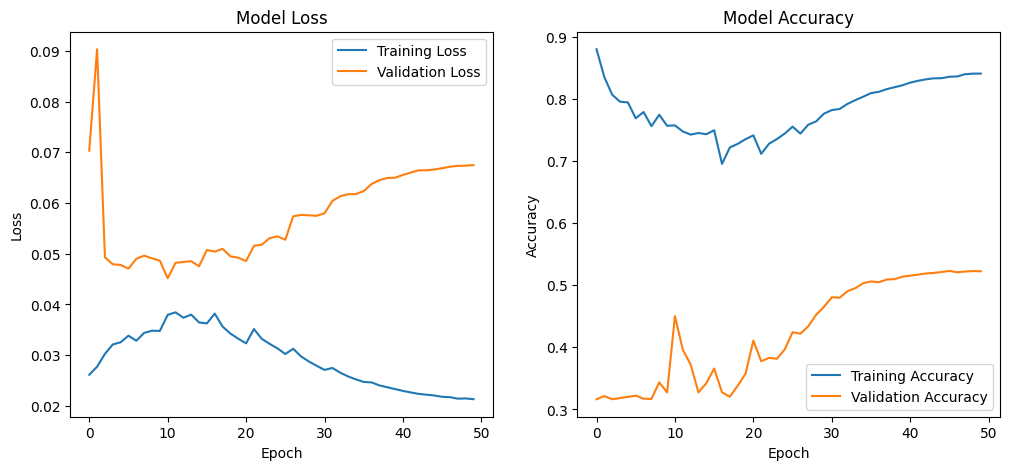

In [44]:
import seaborn as sns
# Evaluate on test set
model_metrics_path = os.path.join(visualisations_path,'Model Matrics')
# Ensure directory exists
if not os.path.exists(model_metrics_path):
    os.makedirs(model_metrics_path)

test_results = model.evaluate(test_dataset)
print(f"Test loss: {test_results[0]}")
print(f"Test accuracy: {test_results[1]}")

# Predictions
y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test_onehot, axis=1)

# Classification report
from sklearn.metrics import classification_report, confusion_matrix
print("\nClassification Report:")
print(classification_report(y_true, y_pred))

# Confusion matrix
conf_matrix = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Failure'],
            yticklabels=['Normal', 'Failure'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.savefig(os.path.join(model_metrics_path, "CM_model_Kwd_Selected_scada_60_2Classes_Strid_4_SMPLModl_FocalLoss_softmax.png"))
plt.show()

# ROC curves
from sklearn.metrics import roc_curve, auc
from itertools import cycle

plt.figure(figsize=(10, 8))
colors = cycle(['blue', 'red', 'green', 'orange', 'purple'])
for i, color in zip(range(num_classes_overall), colors):
    fpr, tpr, _ = roc_curve(y_test_onehot[:, i], y_pred_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f'ROC curve of class {i} (area = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-class ROC')
plt.legend(loc="lower right")
plt.savefig(os.path.join(model_metrics_path, "RocCurve_model_Kwd_Selected_scada_60_2Classes_Strid_4_SMPLModl_FocalLoss_softmax.png"))
plt.show()

# Learning curves
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.savefig(os.path.join(model_metrics_path, "Acc_Loss_model_Kwd_Selected_scada_60_2Classes_Strid_4_SMPLModl_FocalLoss_softmax.png"))
plt.show()

### CV


In [ ]:
# from sklearn.model_selection import TimeSeriesSplit
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import LSTM, Dense, Dropout
# from tensorflow.keras.utils import to_categorical
# from sklearn.metrics import classification_report, confusion_matrix
# import numpy as np

# # Parameters
# sequence_length = 50  # Reasonable for 300k samples
# n_features = len([col for col in df.columns if col not in ['Timestamp', 'Turbine_ID', 'Label', 'YearMonth']])
# n_classes = 6
# batch_size = 256
# epochs = 20

# # Prepare data
# df_sorted = df.sort_values(['Turbine_ID','Timestamp']).reset_index(drop=True)
# X = df_sorted.drop(['Timestamp', 'Turbine_ID', 'Label', 'YearMonth'], axis=1).values
# y = df_sorted['Label'].values

# # Create sequences
# def create_sequences(X, y, seq_length):
#     Xs, ys = [], []
#     for i in range(len(X) - seq_length):
#         Xs.append(X[i:i+seq_length])
#         ys.append(y[i+seq_length])
#     return np.array(Xs), np.array(ys)

# X_seq, y_seq = create_sequences(X, y, sequence_length)
# y_cat = to_categorical(y_seq, n_classes)

# # Calculate class weights
# from sklearn.utils.class_weight import compute_class_weight
# class_weights = compute_class_weight('balanced', classes=np.unique(y_seq), y=y_seq)
# class_weight_dict = {i: class_weights[i] for i in range(len(class_weights))}

# # Time Series Cross Validation
# tscv = TimeSeriesSplit(n_splits=4)
# fold = 1

# for train_idx, val_idx in tscv.split(X_seq):
#     print(f"\n{'='*50}")
#     print(f"Fold {fold}")
#     print(f"{'='*50}")

#     X_train, X_val = X_seq[train_idx], X_seq[val_idx]
#     y_train, y_val = y_cat[train_idx], y_cat[val_idx]

#     # Check class distribution
#     print(f"Train classes: {np.unique(np.argmax(y_train, axis=1), return_counts=True)}")
#     print(f"Val classes: {np.unique(np.argmax(y_val, axis=1), return_counts=True)}")

#     # Build model
#     model = Sequential([
#         LSTM(64, input_shape=(sequence_length, n_features), return_sequences=True),
#         Dropout(0.3),
#         LSTM(32),
#         Dropout(0.3),
#         Dense(n_classes, activation='softmax')
#     ])

#     model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

#     # Train
#     history = model.fit(X_train, y_train,
#                        validation_data=(X_val, y_val),
#                        epochs=epochs,
#                        batch_size=batch_size,
#                        class_weight=class_weight_dict,
#                        verbose=1)

#     # Evaluate
#     y_pred = np.argmax(model.predict(X_val, batch_size=batch_size), axis=1)
#     y_true = np.argmax(y_val, axis=1)

#     print(f"\nFold {fold} Results:")
#     print(classification_report(y_true, y_pred))
#     print("\nConfusion Matrix:")
#     print(confusion_matrix(y_true, y_pred))

#     fold += 1

# print("\nTime Series CV Complete")

### Decision Tree

In [ ]:
# # --- Decision Tree Baseline Experiment ---
# from sklearn.tree import DecisionTreeClassifier
# from sklearn.metrics import classification_report, confusion_matrix
# import seaborn as sns
# import matplotlib.pyplot as plt

# print("\n" + "="*50)
# print("Running Decision Tree Baseline Experiment")
# print("="*50)

# # Flatten the windowed data for Decision Tree (samples, window_size * features)
# # X_train is (samples, 144, features) -> (samples, 144 * features)
# n_samples_train, window_size, n_features = X_train.shape
# X_train_flat = X_train.reshape(n_samples_train, -1)

# n_samples_test, _, _ = X_test.shape
# X_test_flat = X_test.reshape(n_samples_test, -1)

# print(f"Flattened Train Shape: {X_train_flat.shape}")
# print(f"Flattened Test Shape: {X_test_flat.shape}")

# # Initialize Decision Tree
# # Using class_weight='balanced' to handle imbalance automatically
# dt_model = DecisionTreeClassifier(random_state=42, class_weight='balanced')

# # Train
# print("Training Decision Tree...")
# dt_model.fit(X_train_flat, y_train)
# print("Training Complete.")

# # Predict
# y_pred_dt = dt_model.predict(X_test_flat)

# # Evaluate
# print("\nDecision Tree Classification Report:")
# print(classification_report(y_test, y_pred_dt))

# # Confusion Matrix
# conf_matrix_dt = confusion_matrix(y_test, y_pred_dt)
# plt.figure(figsize=(10, 8))
# sns.heatmap(conf_matrix_dt, annot=True, fmt='d', cmap='Blues',
#             xticklabels=['Normal', 'Gearbox','TRANSFORMER','GENERATOR','HYDRAULIC_GROUP'],
#             yticklabels=['Normal', 'Gearbox','TRANSFORMER','GENERATOR','HYDRAULIC_GROUP'])
# plt.xlabel('Predicted')
# plt.ylabel('Actual')
# plt.title('Confusion Matrix - Decision Tree Baseline')
# plt.show()

### XGBoost

In [ ]:
# # --- Advanced XGBoost Experiment (EXP-004) ---
# import xgboost as xgb
# from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
# import seaborn as sns
# import matplotlib.pyplot as plt
# import numpy as np

# print("\n" + "="*50)
# print("Running Advanced XGBoost Experiment (EXP-004)")
# print("="*50)

# # Ensure data is flattened (reusing X_train_flat, X_test_flat from DT experiment)
# # If not defined, redefine:
# if 'X_train_flat' not in locals():
#     n_samples_train, window_size, n_features = X_train.shape
#     X_train_flat = X_train.reshape(n_samples_train, -1)
#     n_samples_test, _, _ = X_test.shape
#     X_test_flat = X_test.reshape(n_samples_test, -1)

# # Calculate class weights for XGBoost (scale_pos_weight is for binary, for multi-class we use sample weights)
# from sklearn.utils.class_weight import compute_sample_weight
# sample_weights = compute_sample_weight(
#     class_weight='balanced',
#     y=y_train
# )

# # XGBoost Configuration
# xgb_params = {
#     'objective': 'multi:softprob',  # Multiclass classification
#     'num_class': len(np.unique(y_train)), # Number of classes
#     'learning_rate': 0.1,
#     'max_depth': 6,                 # Depth of trees
#     'subsample': 0.8,               # Fraction of samples used for fitting trees
#     'colsample_bytree': 0.8,        # Fraction of features used for fitting trees
#     'n_estimators': 100,            # Number of trees
#     'eval_metric': 'mlogloss',
#     'seed': 42,
#     'tree_method': 'hist',          # Faster training for large datasets
#     'device': 'cuda' if tf.config.list_physical_devices('GPU') else 'cpu' # Use GPU if available
# }

# print(f"Training XGBoost with params: {xgb_params}")

# # Initialize and Train
# xgb_model = xgb.XGBClassifier(**xgb_params)
# xgb_model.fit(
#     X_train_flat,
#     y_train,
#     sample_weight=sample_weights,
#     eval_set=[(X_train_flat, y_train), (X_test_flat, y_test)],
#     verbose=10
# )

# print("Training Complete.")

# # Predict
# y_pred_xgb = xgb_model.predict(X_test_flat)

# # Evaluate
# print("\nXGBoost Classification Report:")
# print(classification_report(y_test, y_pred_xgb))

# # Confusion Matrix
# conf_matrix_xgb = confusion_matrix(y_test, y_pred_xgb)
# plt.figure(figsize=(10, 8))
# sns.heatmap(conf_matrix_xgb, annot=True, fmt='d', cmap='Greens',
#             xticklabels=['Normal', 'Gearbox','TRANSFORMER','GENERATOR','HYDRAULIC_GROUP'],
#             yticklabels=['Normal', 'Gearbox','TRANSFORMER','GENERATOR','HYDRAULIC_GROUP'])
# plt.xlabel('Predicted')
# plt.ylabel('Actual')
# plt.title('Confusion Matrix - XGBoost (EXP-004)')
# plt.show()